# 02. Matplotlib для аналитика данных

Цель — не запомнить десятки параметров, а научиться строить читаемые графики и диагностировать визуальные ошибки.

In [1]:
from pathlib import Path

def find_project_root() -> Path:
    """Ищет корень учебного комплекта по наличию подготовленного датасета."""
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        target = candidate / "data" / "viz.csv"
        if target.exists():
            return candidate
    raise FileNotFoundError("Не найден data/viz.csv")

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "viz.csv"
OUTPUT_DIR = PROJECT_ROOT / "teacher" / "out"
OUTPUT_DIR.mkdir(exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("Data:", DATA_PATH)

Project root: <PROJECT_ROOT>\nData: <PROJECT_ROOT>/data/viz.csv\n

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

print("pandas:", pd.__version__)
import matplotlib
print("matplotlib:", matplotlib.__version__)

pandas: 2.2.3
matplotlib: 3.10.8


In [3]:
df = pd.read_csv(DATA_PATH)
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
print("Shape:", df.shape)
display(df.head())

Shape: (1200, 16)


,order_id,order_date,region,channel,customer_type,category,subcategory,quantity,unit_price,discount_percent,revenue,cost,profit,profit_margin,delivery_days,rating
0,RM-00278,2026-01-01,Санкт-Петербург,Партнеры,Повторный,Электроника,Аксессуары,2,25535.30,15,43410.01,32291.26,11118.75,0.2561,3,5.0
1,RM-00380,2026-01-01,Москва,Онлайн,Повторный,Электроника,Аксессуары,3,27689.11,25,62300.50,41398.18,20902.31,0.3355,3,4.9
2,RM-01198,2026-01-01,Ростов-на-Дону,Онлайн,Повторный,Электроника,Аксессуары,1,28165.80,5,26757.51,17040.27,9717.24,0.3632,6,4.4
3,RM-00014,2026-01-02,Самара,Онлайн,Новый,Электроника,Смартфоны,2,26549.60,20,42479.36,26123.07,16356.29,0.3850,7,4.4
4,RM-00053,2026-01-02,Самара,Онлайн,Повторный,Дом и кухня,Посуда,3,8456.20,10,22831.74,15530.02,7301.72,0.3198,3,4.7


## 1. Распределение заказов: histogram

**Вопрос:** как распределена выручка заказа?

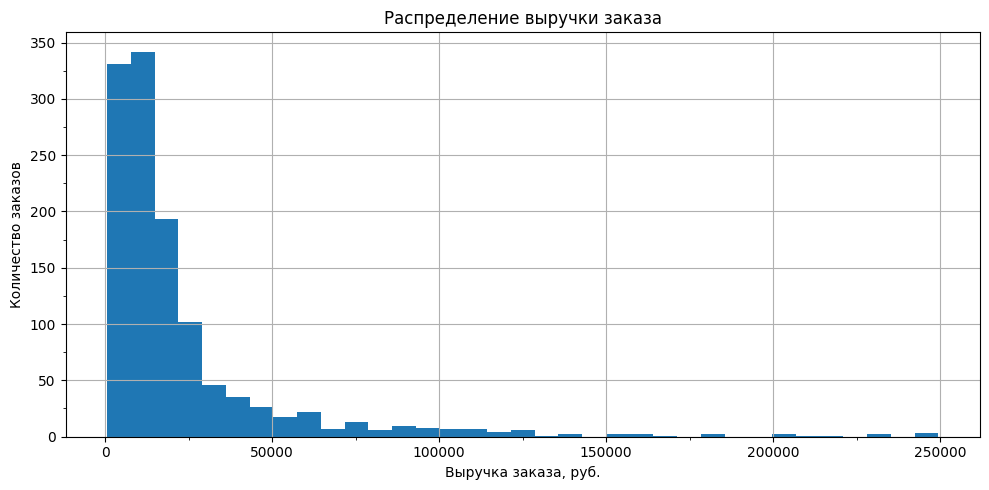

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["revenue"], bins=35)
ax.set_title("Распределение выручки заказа")
ax.set_xlabel("Выручка заказа, руб.")
ax.set_ylabel("Количество заказов")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_revenue_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

### Вопрос

Почему высокий правый хвост не означает автоматически «плохие данные»? Назовите минимум две бизнес-причины.

## 2. Выбросы между категориями: boxplot

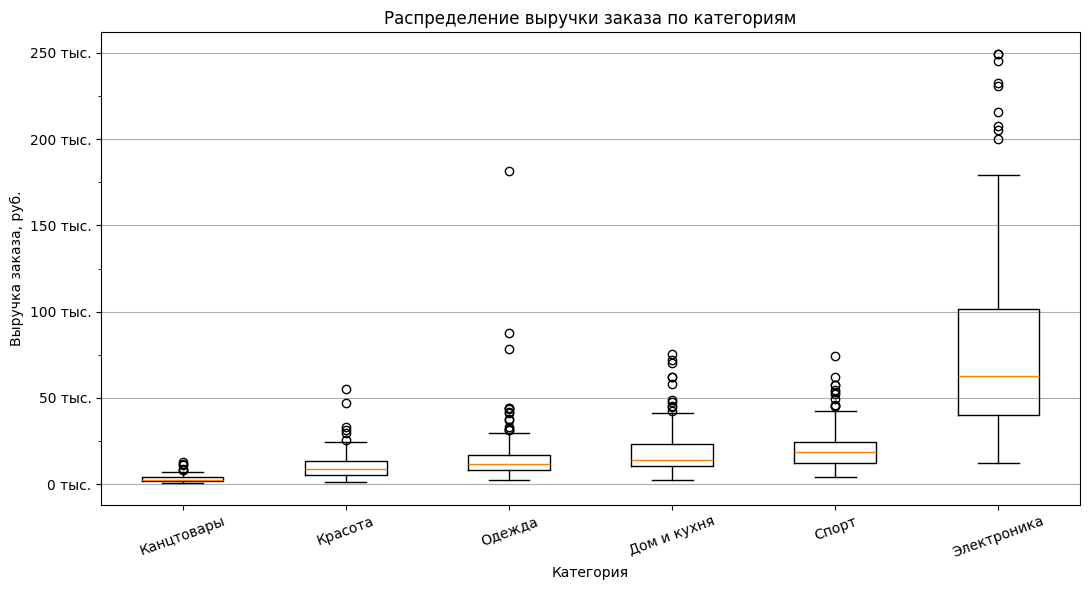

In [5]:
order = df.groupby("category")["revenue"].median().sort_values().index.tolist()
series = [df.loc[df["category"] == c, "revenue"].to_numpy() for c in order]
fig, ax = plt.subplots(figsize=(11, 6))
ax.boxplot(series, tick_labels=order, showfliers=True)
ax.set_title("Распределение выручки заказа по категориям")
ax.set_xlabel("Категория")
ax.set_ylabel("Выручка заказа, руб.")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:.0f} тыс."))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", which="major")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_category_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Связь скидки и прибыли: scatter plot

**Вопрос:** видна ли связь между размером скидки и прибылью заказа?

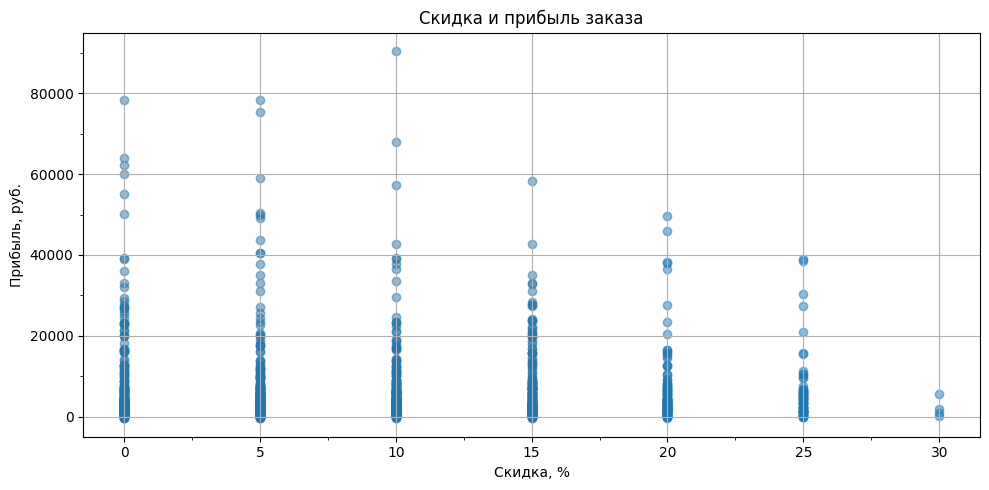

Корреляция: -0.061


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df["discount_percent"], df["profit"], alpha=0.5)
ax.set_title("Скидка и прибыль заказа")
ax.set_xlabel("Скидка, %")
ax.set_ylabel("Прибыль, руб.")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_discount_profit_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Корреляция:", round(df[["discount_percent", "profit"]].corr().iloc[0,1], 3))

> Корреляция не доказывает причинность. На прибыль одновременно влияют цена, количество, категория, тип клиента, себестоимость и другие факторы.

## 4. Динамика по дням: читаемые даты и деления

На этом графике специально показываем major и minor ticks, чтобы точку можно было соотнести с календарем.

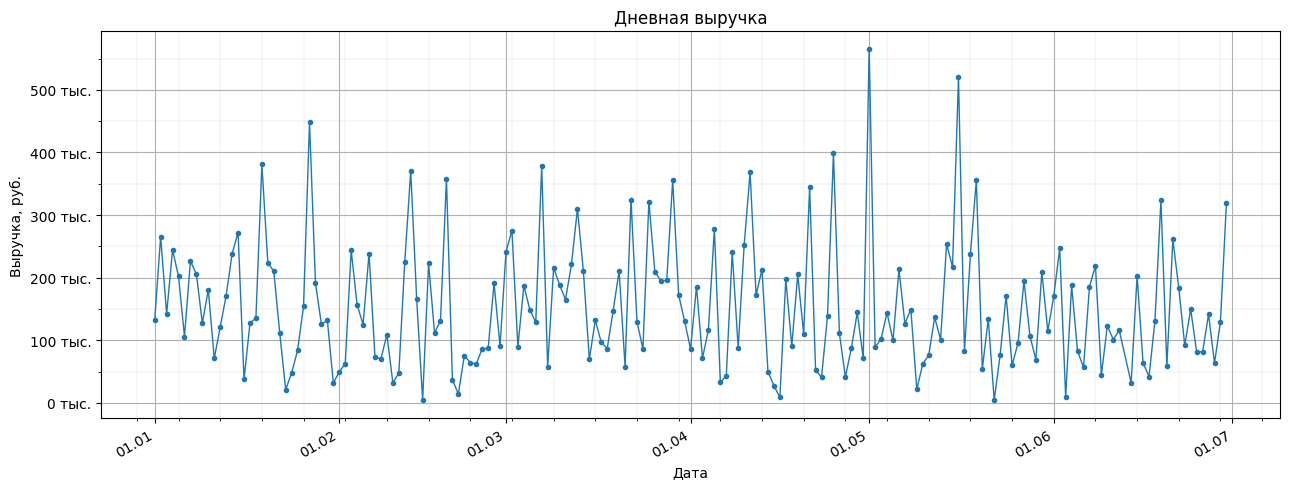

In [7]:
daily = df.groupby("order_date", as_index=False).agg(revenue=("revenue", "sum"))
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily["order_date"], daily["revenue"], marker=".", linewidth=1)
ax.set_title("Дневная выручка")
ax.set_xlabel("Дата")
ax.set_ylabel("Выручка, руб.")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:.0f} тыс."))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major")
ax.grid(True, which="minor", linewidth=0.3, alpha=0.45)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_daily_revenue_ticks.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Визуальная ошибка: обрезанная ось в bar chart

Для столбцов длина — главный канал сравнения. Поэтому обрезанная шкала может сильно преувеличить различие.

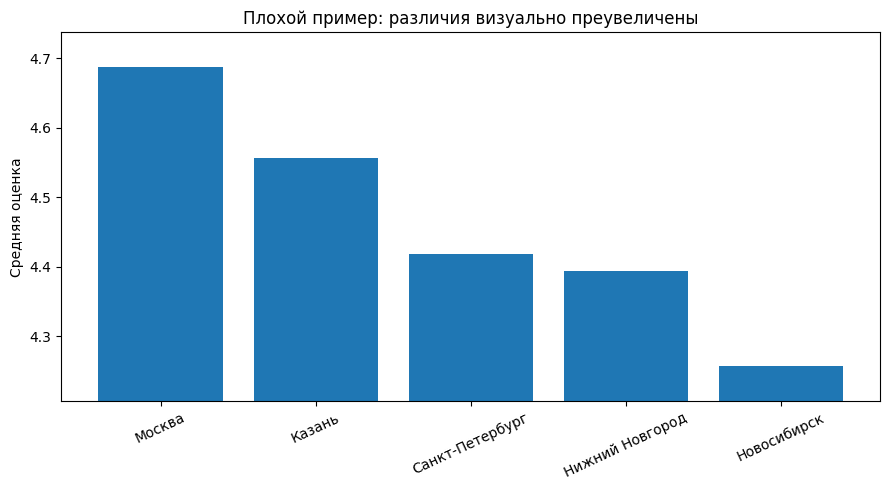

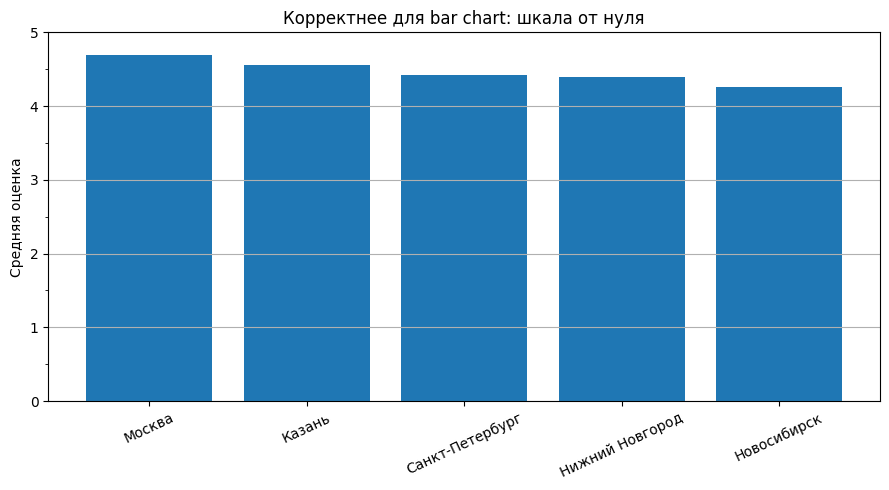

In [8]:
region_avg = (df.groupby("region", as_index=False).agg(avg_rating=("rating", "mean")).sort_values("avg_rating", ascending=False).head(5))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(region_avg["region"], region_avg["avg_rating"])
ax.set_ylim(region_avg["avg_rating"].min()-0.05, region_avg["avg_rating"].max()+0.05)
ax.set_title("Плохой пример: различия визуально преувеличены")
ax.set_ylabel("Средняя оценка")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_bad_truncated_axis.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(region_avg["region"], region_avg["avg_rating"])
ax.set_ylim(0, 5)
ax.set_title("Корректнее для bar chart: шкала от нуля")
ax.set_ylabel("Средняя оценка")
ax.tick_params(axis="x", rotation=25)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, axis="y", which="major")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "08_good_zero_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Мини-практика

Постройте горизонтальный bar chart **прибыли по регионам**.

Требования:

1. сначала агрегируйте данные;
2. отсортируйте регионы;
3. подпишите оси;
4. добавьте major/minor деления по числовой оси;
5. сохраните `outputs/09_region_profit_student.png`;
6. напишите один аналитический вывод.

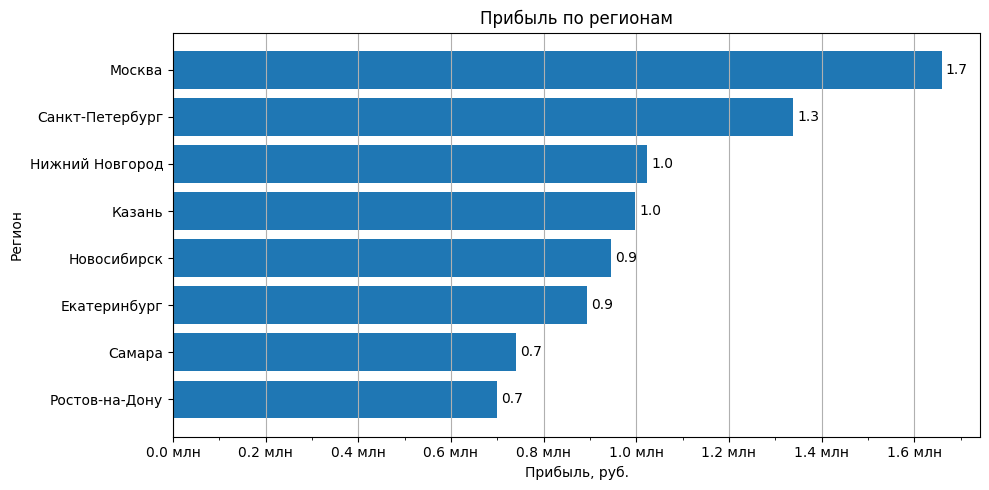

Лидер по прибыли: Москва


In [9]:
region_profit = (
    df.groupby("region", as_index=False)
      .agg(profit=("profit", "sum"))
      .sort_values("profit", ascending=True)
)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(region_profit["region"], region_profit["profit"])
ax.set_title("Прибыль по регионам")
ax.set_xlabel("Прибыль, руб.")
ax.set_ylabel("Регион")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} млн"))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, axis="x", which="major")
ax.bar_label(bars, labels=[f"{v/1_000_000:.1f}" for v in region_profit["profit"]], padding=3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "09_region_profit_solution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Лидер по прибыли:", region_profit.iloc[-1]["region"])

### Эталонная интерпретация

В синтетическом наборе лидер по суммарной прибыли — **Москва**. Для управленческого вывода важно дополнительно проверить размер рынка/число заказов: высокая суммарная прибыль может быть следствием большего объема, а не большей эффективности одного заказа.